In [5]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# Mac인 경우 AppleGothic 폰트 설정
if platform.system() == 'Darwin':  # macOS의 시스템 이름은 'Darwin'입니다.
    plt.rc('font', family='AppleGothic')

# 마이너스 기호(-)가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
print("라이브러리 로드 완료")

라이브러리 로드 완료


In [2]:
def get_sample_size(p_baseline, mde, alpha=0.05, power=0.8):
    """
    p_baseline : 기준 전환율 (예: 0.10 = 10%)
    mde        : 최소감지효과 - 상대적 변화율 (예: 0.10 = 10% 향상)
    alpha      : 유의수준 (기본 0.05)
    power      : 검정력 (기본 0.8)
    """
    p2 = p_baseline * (1 + mde)        # 트리트먼트 전환율
    p_bar = (p_baseline + p2) / 2      # 풀링된 전환율

    z_alpha = stats.norm.ppf(1 - alpha / 2)   # 양측검정
    z_beta  = stats.norm.ppf(power)

    numerator = (
        z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) +
        z_beta  * np.sqrt(p_baseline * (1 - p_baseline) + p2 * (1 - p2))
    ) ** 2
    denominator = (p2 - p_baseline) ** 2

    n = np.ceil(numerator / denominator)
    return int(n), round(p2, 4)


# 테스트
n, p2 = get_sample_size(p_baseline=0.10, mde=0.10)
print(f"기준 전환율: 10%")
print(f"목표 전환율: {p2*100:.1f}%  (MDE +10%)")
print(f"그룹당 필요 표본: {n:,}명")
print(f"총 필요 표본:     {n*2:,}명")

기준 전환율: 10%
목표 전환율: 11.0%  (MDE +10%)
그룹당 필요 표본: 14,751명
총 필요 표본:     29,502명


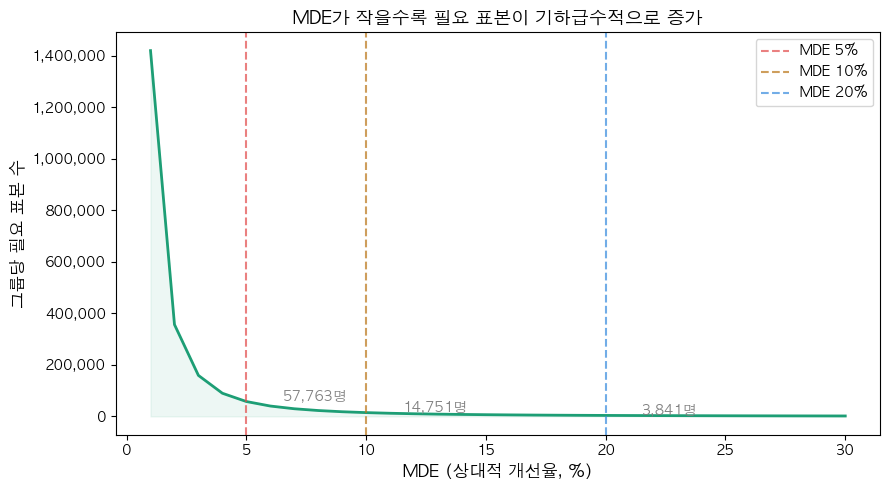

In [6]:
mde_range = np.arange(0.01, 0.31, 0.01)
sample_sizes = [get_sample_size(0.10, m)[0] for m in mde_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mde_range * 100, sample_sizes, color="#1D9E75", linewidth=2)
ax.fill_between(mde_range * 100, sample_sizes, alpha=0.08, color="#1D9E75")

ax.axvline(x=5,  color="#E24B4A", linestyle="--", alpha=0.7, label="MDE 5%")
ax.axvline(x=10, color="#BA7517", linestyle="--", alpha=0.7, label="MDE 10%")
ax.axvline(x=20, color="#378ADD", linestyle="--", alpha=0.7, label="MDE 20%")

for mde, label in [(5, "MDE 5%"), (10, "MDE 10%"), (20, "MDE 20%")]:
    n_val = get_sample_size(0.10, mde/100)[0]
    ax.annotate(
        f"{n_val:,}명",
        xy=(mde, n_val),
        xytext=(mde + 1.5, n_val + 1000),
        fontsize=10, color="gray"
    )

ax.set_xlabel("MDE (상대적 개선율, %)", fontsize=12)
ax.set_ylabel("그룹당 필요 표본 수", fontsize=12)
ax.set_title("MDE가 작을수록 필요 표본이 기하급수적으로 증가", fontsize=13)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

In [7]:
def simulate_false_positive_rate(n_simulations=1000, n_per_group=500, alpha=0.05):
    """
    실제로 효과가 없는데 (p_A = p_B = 0.10)
    유의하다고 판단하는 비율 = False Positive Rate
    이론상 alpha(0.05)와 같아야 정상
    """
    false_positives = 0

    for _ in range(n_simulations):
        group_a = np.random.binomial(1, 0.10, n_per_group)
        group_b = np.random.binomial(1, 0.10, n_per_group)  # 효과 없음

        p_a = group_a.mean()
        p_b = group_b.mean()
        p_pool = (group_a.sum() + group_b.sum()) / (2 * n_per_group)

        se = np.sqrt(p_pool * (1 - p_pool) * (2 / n_per_group))
        z = (p_b - p_a) / se if se > 0 else 0
        p_value = 2 * (1 - stats.norm.cdf(abs(z)))

        if p_value < alpha:
            false_positives += 1

    return false_positives / n_simulations


fpr = simulate_false_positive_rate()
print(f"시뮬레이션 False Positive Rate: {fpr:.3f}")
print(f"이론값 (alpha):                 0.050")
print(f"차이:                           {abs(fpr - 0.05):.3f}")
print()
print("→ 효과가 없는데도 약 5%의 실험에서 '유의하다'고 잘못 판단함")
print("→ 1000번 실험하면 약 50번은 틀린 결론을 내리는 것")

시뮬레이션 False Positive Rate: 0.057
이론값 (alpha):                 0.050
차이:                           0.007

→ 효과가 없는데도 약 5%의 실험에서 '유의하다'고 잘못 판단함
→ 1000번 실험하면 약 50번은 틀린 결론을 내리는 것
